# Notebook 1: Repository-Level Evaluation

**Goal:** Explain what happened for a single target repository.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `generated_tests.csv`, `failure_cases.csv`

**RQs addressed:** RQ1, RQ2, RQ3, RQ7, RQ8, RQ9

In [1]:
# repo_name is injected by papermill when running via `analysis repo-report`.
# When running interactively this cell is a no-op and the notebook uses all repos.
if 'repo_name' not in dir():
    repo_name = None

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.normalize import build_candidate_summary
from analysis.plots import (
    outcome_funnel,
    stacked_outcome_bar,
    metric_delta_distribution,
    before_after_slope,
    cost_vs_improvement_scatter,
    failure_category_bar,
)

sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
FAILURE_DIR = DATA_DIR / 'failures'
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')

attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
gen_tests  = pd.read_csv(DATA_DIR / 'generated_tests.csv') if (DATA_DIR / 'generated_tests.csv').exists() else pd.DataFrame()
failures   = pd.read_csv(FAILURE_DIR / 'failure_cases.csv') if (FAILURE_DIR / 'failure_cases.csv').exists() else pd.DataFrame()

In [3]:
# â”€â”€ Select repository â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# repo_name injected by papermill â†’ single-repo report mode.
# Running interactively with repo_name=None â†’ uses first repo in the dataset.
if repo_name and repo_name in attempts['repo_name'].values:
    REPO_NAME  = repo_name
    REPO_OWNER = attempts.loc[attempts['repo_name'] == REPO_NAME, 'repo_owner'].iloc[0]
else:
    if repo_name:
        print(f'[warn] repo_name={repo_name!r} not found â€” falling back to first repo.')
    _first = attempts[['repo_owner', 'repo_name']].drop_duplicates().iloc[0]
    REPO_OWNER = _first['repo_owner']
    REPO_NAME  = _first['repo_name']

COMMIT_HASH = None   # None = any commit

mask = (attempts['repo_owner'] == REPO_OWNER) & (attempts['repo_name'] == REPO_NAME)
if COMMIT_HASH:
    mask &= attempts['commit_hash'] == COMMIT_HASH

repo_attempts   = attempts[mask].copy()
repo_candidates = candidates[candidates['repo_name'] == REPO_NAME].copy()
print(f'Repository:       {REPO_OWNER}/{REPO_NAME}')
print(f'Attempts in repo: {len(repo_attempts)}')
print(f'Candidates:       {len(repo_candidates)}')

Repository:       consulthunter/TestMap-Example
Attempts in repo: 7
Candidates:       2


## 1. Repository Scope and Baseline

Records the repository identifier and commit hash, and reports the pre-existing coverage and mutation scores as the baseline against which all deltas are measured.


In [4]:
# Baseline coverage and mutation scores, candidate count, project count
print(repo_attempts[['repo_owner', 'repo_name', 'commit_hash']].drop_duplicates())
print('\nCoverage before (median):', repo_attempts['coverage_before'].median())
print('Mutation score before (median):', repo_attempts['mutation_score_before'].median())

      repo_owner        repo_name                               commit_hash
0  consulthunter  TestMap-Example  867ab17d3141bc0e6d696486bd8edb67546c00d1

Coverage before (median): 0.6521739130434783
Mutation score before (median): 22.22222222222222


## 2. Lane Outcome Funnels

Shows how many attempts cleared each pipeline stage for each lane:

| Stage | Meaning |
|---|---|
| total | All attempts |
| produced_change | Generated output (no generation failure) |
| build_passed | Output compiled successfully |
| tests_passed | Generated tests ran and passed (VEP + VLI) |
| validated | Tests passed **and** metrics improved â‰¥ noise floor (VEP only) |

The gap between each bar is the count lost at that stage, which localises where each lane primarily fails.


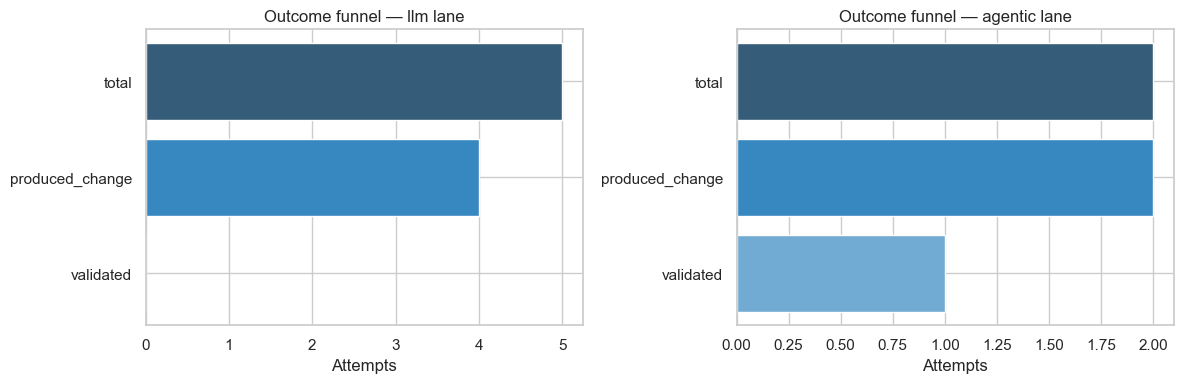

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
outcome_funnel(repo_attempts, lane='llm',     ax=axes[0])
outcome_funnel(repo_attempts, lane='agentic', ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Candidate-Level Results

Collapses attempts to one row per (candidate, lane) using the best attempt selection rule (validated success > highest coverage_delta > first). This is the unit of analysis for the primary lane comparison.

`any_validated_success` uses the broad definition (VEP or VLI). `validated_evidence_positive_count` and `validated_low_impact_count` show how many attempts reached each outcome, separating tests that improved metrics from those that merely passed.


In [ ]:
display_cols = [c for c in [
    'candidate_key', 'lane', 'any_validated_success',
    'validated_evidence_positive_count', 'validated_low_impact_count',
    'best_coverage_delta', 'best_mutation_delta', 'attempt_count'
] if c in repo_candidates.columns]
repo_candidates[display_cols].sort_values('any_validated_success', ascending=False).head(20)


## 4. Generated Test Volume and Quality

Lists the individual generated tests produced in this repository. Agentic attempts may produce multiple tests per invocation; the `generated_test_count` column on the attempt table tracks this. This section shows the per-test grain before collapse.


In [7]:
if not gen_tests.empty:
    repo_tests = gen_tests[gen_tests.get('repo_name', pd.Series()) == REPO_NAME]
    print(f'Generated tests for this repo: {len(repo_tests)}')
    display(repo_tests.head(10))
else:
    print('No generated_tests.csv available.')

Generated tests for this repo: 15


,experiment_run_id,lane,tool_id,tool_run_status,tool_validation_outcome,tool_artifact_path,changed_files_count,tool_attempt_targeted_baseline_id,tool_post_attempt_test_run_id,repo_url,...,validated_evidence_positive,validated_low_impact,validated_success,positive_impact,impact_attribution,produced_change,baseline_test_smell_count,baseline_test_smell_types,generated_test_smell_count,generated_test_smell_types
0,1,llm,NaN,NaN,NaN,NaN,0,NaN,NaN,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],2,"[""Duplicate Assertion Test Smell""]"
1,1,llm,NaN,NaN,NaN,NaN,0,NaN,NaN,https://github.com/consulthunter/TestMap-Example,...,False,False,False,False,attempt_level,False,0,[],2,"[""Duplicate Assertion Test Smell""]"
2,1,llm,NaN,NaN,NaN,NaN,0,NaN,NaN,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],2,"[""Duplicate Assertion Test Smell""]"
3,1,llm,NaN,NaN,NaN,NaN,0,NaN,NaN,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],2,"[""Duplicate Assertion Test Smell""]"
4,1,llm,NaN,NaN,NaN,NaN,0,NaN,NaN,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],2,"[""Duplicate Assertion Test Smell""]"
5,1,agentic,codex,Completed,Passed,D:\Projects\TestMap\TestMap\Output\consulthunt...,1,3.0,13.0,https://github.com/consulthunter/TestMap-Example,...,True,False,True,True,attempt_level,True,0,[],2,"[""Duplicate Assertion Test Smell"", ""Eager Test..."
6,1,agentic,codex,Completed,Passed,D:\Projects\TestMap\TestMap\Output\consulthunt...,1,3.0,13.0,https://github.com/consulthunter/TestMap-Example,...,True,False,True,True,attempt_level,True,0,[],0,[]
7,1,agentic,gemini,Completed,TestsFailed,D:\Projects\TestMap\TestMap\Output\consulthunt...,1,3.0,14.0,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],1,"[""Duplicate Assertion Test Smell""]"
8,1,agentic,gemini,Completed,TestsFailed,D:\Projects\TestMap\TestMap\Output\consulthunt...,1,3.0,14.0,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],0,[]
9,1,agentic,gemini,Completed,TestsFailed,D:\Projects\TestMap\TestMap\Output\consulthunt...,1,3.0,14.0,https://github.com/consulthunter/TestMap-Example,...,False,False,False,True,attempt_level,True,0,[],1,"[""Duplicate Assertion Test Smell""]"


## 5. Coverage and Mutation Movement

Slope (spaghetti) chart of before â†’ after metric values per attempt. Each line is one attempt; the mean overlay shows the typical direction of change. **Note:** this section includes all attempts regardless of outcome â€” failed attempts that did not modify code will show a flat line, which can understate the movement seen by successful attempts.


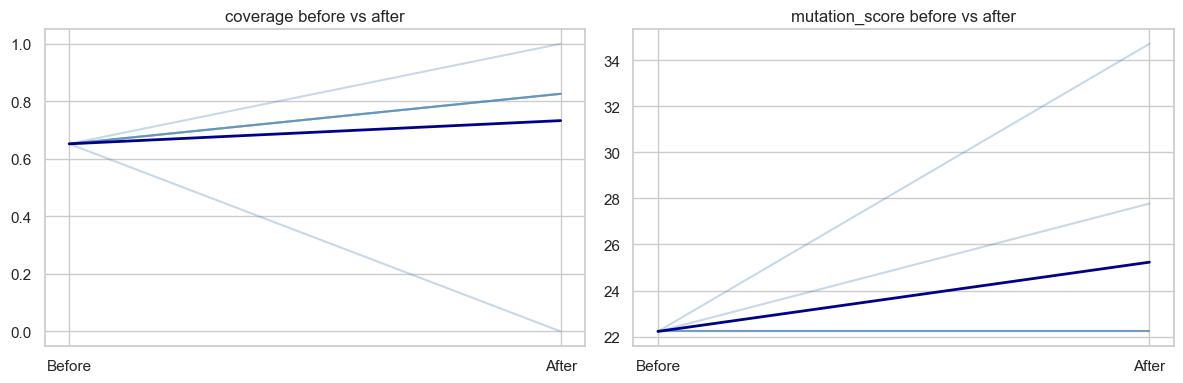

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_after_slope(repo_attempts, 'coverage_before', 'coverage_after', ax=axes[0])
before_after_slope(repo_attempts, 'mutation_score_before', 'mutation_score_after', ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Cost and Runtime

Four scatter plots of resource use (wall-clock time and total tokens) against the two metric deltas (coverage and mutation score), coloured by lane. Together they answer whether higher-cost attempts are buying better outcomes. Followed by median/total summary statistics per lane.

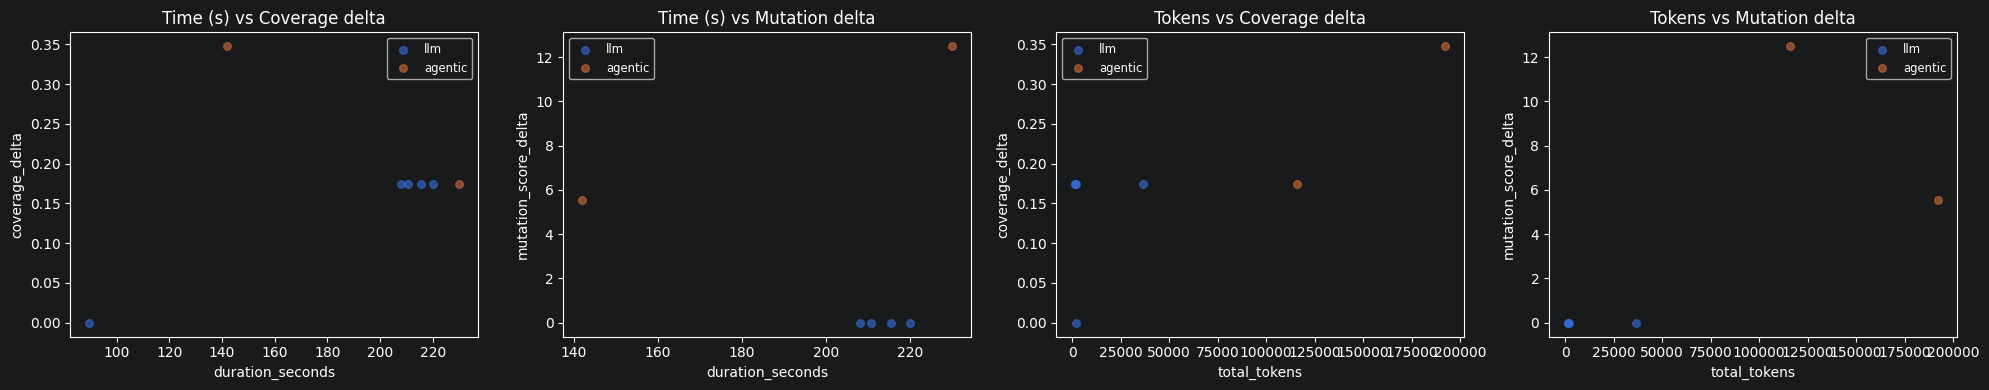

        duration_seconds             total_tokens        
                  median         sum       median     sum
lane                                                     
agentic       185.897912  371.795824     153959.0  307918
llm           210.646567  943.291858       1782.0   43316


In [19]:
if 'duration_seconds' in repo_attempts.columns:
    pairs = [
        ('duration_seconds',  'coverage_delta',        'Time (s) vs Coverage delta'),
        ('duration_seconds',  'mutation_score_delta',   'Time (s) vs Mutation delta'),
        ('total_tokens',      'coverage_delta',         'Tokens vs Coverage delta'),
        ('total_tokens',      'mutation_score_delta',    'Tokens vs Mutation delta'),
    ]
    available = [(x, y, t) for x, y, t in pairs
                 if x in repo_attempts.columns and y in repo_attempts.columns]
    if available:
        fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
        if len(available) == 1:
            axes = [axes]
        for ax, (x_col, y_col, title) in zip(axes, available):
            cost_vs_improvement_scatter(repo_attempts, x_col, y_col, 'lane', ax=ax)
            ax.set_title(title)
        plt.tight_layout()
        plt.show()

summary_cols = [c for c in ['duration_seconds', 'total_tokens'] if c in repo_attempts.columns]
if summary_cols:
    print(repo_attempts.groupby('lane')[summary_cols].agg(['median', 'sum']))

## 7. Agentic Change Footprint

Counts how many files the agentic lane touched beyond the target test file per attempt: `changed_files_count`, `test_files_changed`, `production_files_changed`, `project_files_changed`, `deleted_files_count`. Any non-zero `production_files_changed` rate is a correctness risk.


In [25]:
agentic = repo_attempts[repo_attempts['lane'] == 'agentic']
footprint_cols = [c for c in [
    'changed_files_count', 'test_files_changed',
    'production_files_changed', 'project_files_changed', 'deleted_files_count',
] if c in agentic.columns]

if not footprint_cols:
    print('No footprint columns available.')
else:
    display(agentic[footprint_cols].describe().T.round(2))

    # Footprint distributions
    fig, axes = plt.subplots(1, len(footprint_cols), figsize=(4 * len(footprint_cols), 4))
    if len(footprint_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, footprint_cols):
        vals = agentic[col].dropna()
        if len(vals) == 0:
            ax.set_visible(False)
            continue
        max_val = int(vals.max())
        bins = list(range(max_val + 2)) if max_val >= 1 else [-0.5, 0.5, 1.5]
        ax.hist(vals, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
        ax.set_title(col.replace('_', ' '))
        ax.set_xlabel('file count')
        ax.set_ylabel('attempts')
    plt.suptitle('Agentic change footprint distributions')
    plt.tight_layout()
    plt.show()

    # Production-change rate by tool
    if 'production_files_changed' in agentic.columns and 'tool_id' in agentic.columns:
        prod_rate = (
            agentic.groupby('tool_id')
            .apply(lambda g: (g['production_files_changed'].fillna(0) > 0).mean())
            .rename('production_change_rate')
        )
        print('\nProduction-file change rate by tool:')
        print(prod_rate.round(3))

    # Change footprint vs validation outcome
    if 'changed_files_count' in agentic.columns and 'validated_success' in agentic.columns:
        valid_fp = agentic.dropna(subset=['changed_files_count', 'validated_success'])
        if len(valid_fp) > 0:
            fig, ax = plt.subplots(figsize=(8, 4))
            max_val = int(valid_fp['changed_files_count'].max())
            bins = list(range(max_val + 2)) if max_val >= 1 else [-0.5, 0.5, 1.5]
            for success_val, label, color in [
                (True, 'success', 'steelblue'), (False, 'failure', 'salmon')
            ]:
                sub = valid_fp[valid_fp['validated_success'] == success_val]['changed_files_count']
                ax.hist(sub, bins=bins, alpha=0.6, label=label, color=color)
            ax.set_xlabel('changed_files_count')
            ax.set_ylabel('attempts')
            ax.set_title('Change footprint by outcome')
            ax.legend()
            plt.tight_layout()
            plt.show()


## 8. LLM Failure Taxonomy and Roslyn Diagnostics

Breaks down LLM lane failures by `failure_category` (generation, compile, test, application). Roslyn static analysis diagnostics count how many new compiler warnings or errors were introduced by the generated test.


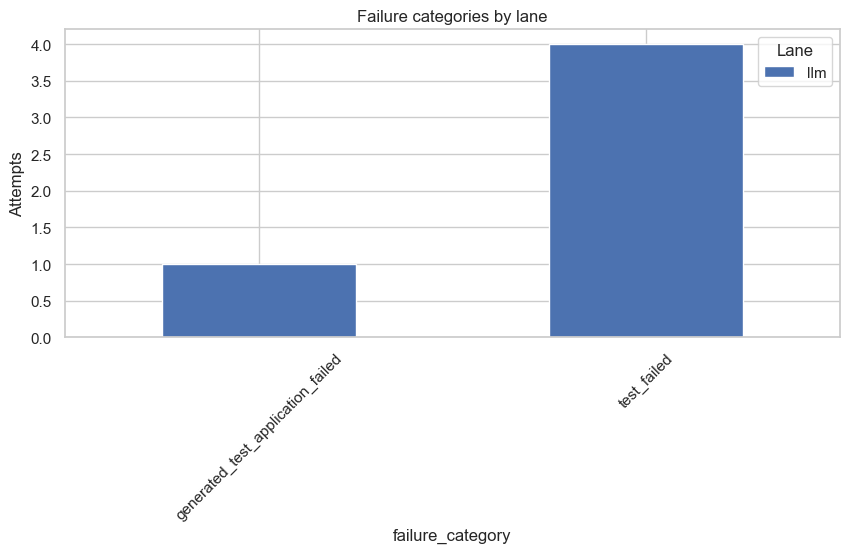

In [11]:
llm = repo_attempts[repo_attempts['lane'] == 'llm']
fig, ax = plt.subplots(figsize=(10, 4))
failure_category_bar(llm, lane_col='lane', category_col='failure_category', ax=ax)
plt.show()

## 9. Agentic Failure Outcomes

Stacked bar of `tool_validation_outcome` values per agentic tool. Shows the mix of Passed / TestsFailed / BuildFailed / TimedOut etc. per tool within this repository.


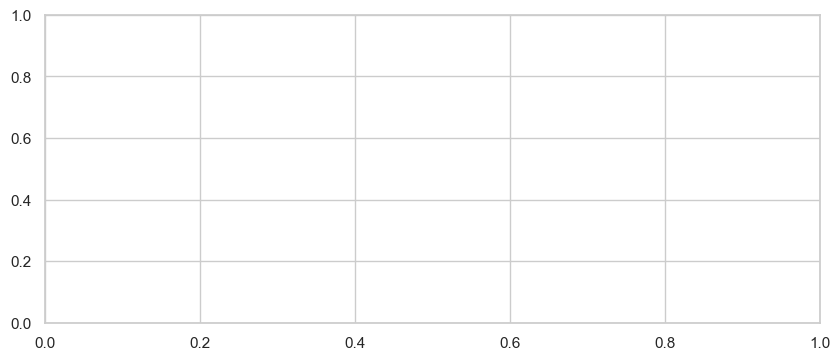

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
stacked_outcome_bar(agentic, group_col='tool_id', outcome_col='observed_outcome', ax=ax)
plt.show()

## 10. Qualitative Failure Case Sample

Lists the sampled failure cases for this repository, linked to their preliminary machine labels. These cases are the input for later open coding in Notebook 5. Run `python -m analysis export-failures ... --markdown` first.


In [13]:
if not failures.empty:
    repo_failures = failures[failures.get('repo_name', pd.Series()) == REPO_NAME]
    cols = [c for c in ['failure_case_id', 'lane', 'preliminary_failure_label', 'source_method_name', 'outcome_summary'] if c in repo_failures.columns]
    repo_failures[cols].head(10)
else:
    print('No failure_cases.csv available. Run: python -m analysis export-failures ...')

## 11. Repository Summary

Prints the full overview JSON for this repository: scope counts, outcome counts (broken down by VEP / VLI / FEP etc.), metric movement, cost, and data completeness. This is the machine-readable summary that backs the cross-repository overview in Notebook 2.


In [14]:
from analysis.summaries import build_overview
import json

overview = build_overview(repo_attempts)
print(json.dumps(overview, indent=2, default=str))

{
  "scope": {
    "repositories_evaluated": 1,
    "candidates_evaluated": 1,
    "total_attempts": 7,
    "llm_attempts": 5,
    "agentic_attempts": 2,
    "models_evaluated": 3,
    "tools_evaluated": 2
  },
  "generated_tests": {
    "generated_tests_total": 15,
    "generated_tests_llm": 5,
    "generated_tests_agentic": 10,
    "candidates_with_at_least_one_test": 1,
    "candidates_with_multiple_tests": 1
  },
  "outcomes": {
    "validated_successes": 1,
    "positive_impact_attempts": 6,
    "validated_evidence_positive_attempts": 1,
    "validated_low_impact_attempts": 0,
    "outcome_validatedevidencepositive_total": 1,
    "outcome_validatedevidencepositive_llm": 0,
    "outcome_validatedevidencepositive_agentic": 1,
    "outcome_validatedlowimpact_total": 0,
    "outcome_validatedlowimpact_llm": 0,
    "outcome_validatedlowimpact_agentic": 0,
    "outcome_failedevidencepositive_total": 4,
    "outcome_failedevidencepositive_llm": 4,
    "outcome_failedevidencepositive_agen

## 12. Outcome Classification

`outcome_classification` is the authoritative outcome label for both lanes:
- **ValidatedEvidencePositive** â€” test generated, compiled, executed, and passed
- **FailedEvidencePositive** â€” test generated and ran but produced a failure
- **ValidationFailed** â€” generation or build failed before tests could run

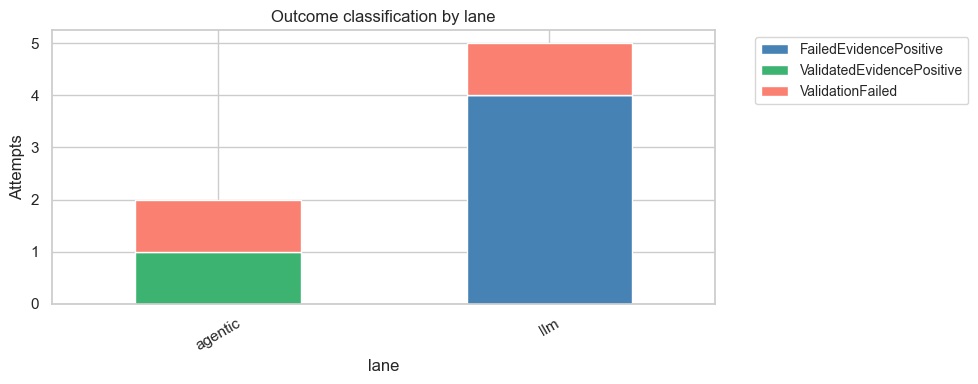


Counts:
outcome_classification  FailedEvidencePositive  ValidatedEvidencePositive  \
lane                                                                        
agentic                                      0                          1   
llm                                          4                          0   

outcome_classification  ValidationFailed  
lane                                      
agentic                                1  
llm                                    1  


In [15]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in repo_attempts.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    outcome_classification_bar(repo_attempts, group_col='lane', ax=ax)
    plt.tight_layout()
    plt.show()

    print('\nCounts:')
    print(repo_attempts.groupby(['lane', 'outcome_classification']).size().unstack(fill_value=0))
else:
    print('outcome_classification column not found.')

## 13. Source Method Characteristics

Distribution of structural metrics for the target source methods in this repository: cyclomatic complexity, maintainability index, SLOC, coupling. Characterises the difficulty profile of the evaluation candidates.


,count,mean,std,min,25%,50%,75%,max
source_method_cc,7.0,8.00,0.0,8.00,8.00,8.00,8.00,8.00
source_method_mi,7.0,64.00,0.0,64.00,64.00,64.00,64.00,64.00
source_method_coupling,7.0,3.00,0.0,3.00,3.00,3.00,3.00,3.00
source_method_dit,7.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
source_method_sloc,7.0,36.00,0.0,36.00,36.00,36.00,36.00,36.00
source_method_baseline_coverage,7.0,0.65,0.0,0.65,0.65,0.65,0.65,0.65


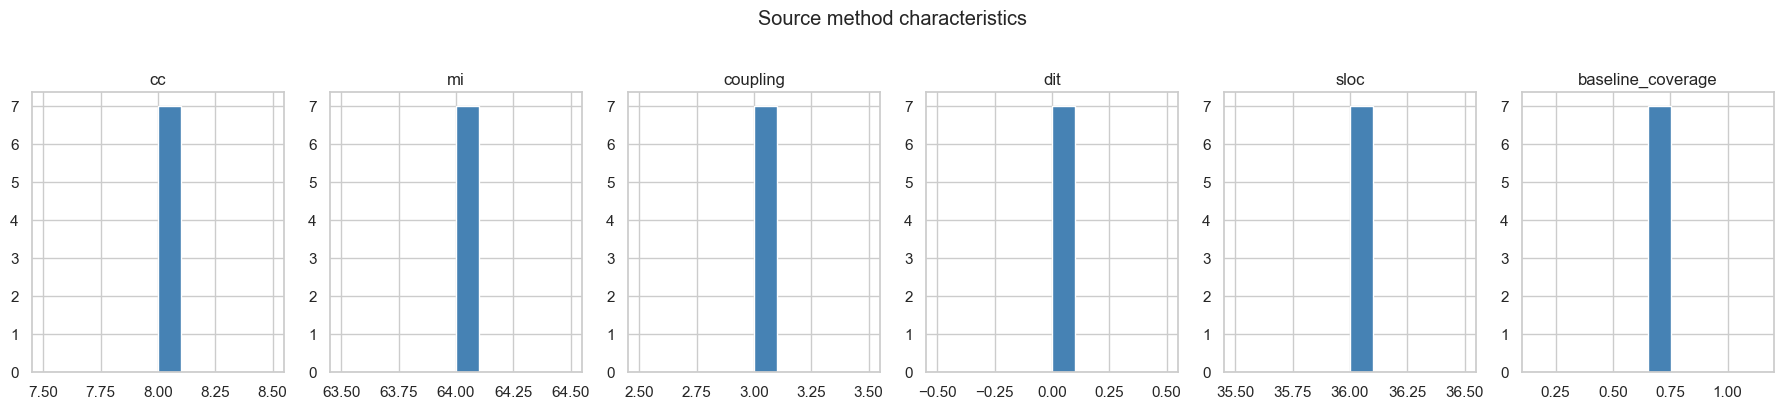

In [16]:
source_metric_cols = [c for c in [
    'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_dit', 'source_method_sloc', 'source_method_baseline_coverage',
] if c in repo_attempts.columns]

if source_metric_cols:
    display(repo_attempts[source_metric_cols].describe().T.round(2))

    fig, axes = plt.subplots(1, len(source_metric_cols), figsize=(3 * len(source_metric_cols), 4))
    if len(source_metric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, source_metric_cols):
        repo_attempts[col].dropna().hist(bins=10, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col.replace('source_method_', ''))
    plt.suptitle('Source method characteristics', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Source method metric columns not found in dataset.')

## 14. Code Metrics: Baseline Test vs Generated Test

Slope charts comparing structural metrics of the **baseline tests** (existing) against the **generated tests** (output). Each line is one attempt; the mean overlay shows the typical direction of transformation. Includes all attempts regardless of outcome.

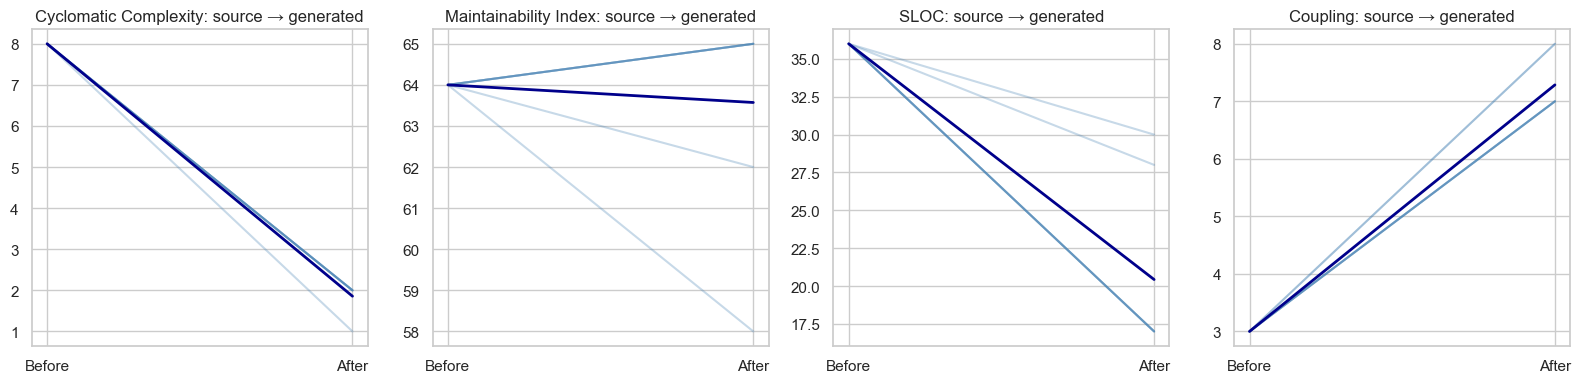

,median
source_method_cc,8.0
generated_test_cc,2.0
source_method_mi,64.0
generated_test_mi,65.0
source_method_sloc,36.0
generated_test_sloc,17.0


In [17]:
from analysis.plots import before_after_slope

metric_pairs = [
    ('baseline_test_cc',       'generated_test_cc',       'Cyclomatic Complexity'),
    ('baseline_test_mi',       'generated_test_mi',       'Maintainability Index'),
    ('baseline_test_sloc',     'generated_test_sloc',     'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
available_pairs = [(b, g, lbl) for b, g, lbl in metric_pairs
                   if b in repo_attempts.columns and g in repo_attempts.columns]

if available_pairs:
    fig, axes = plt.subplots(1, len(available_pairs), figsize=(4 * len(available_pairs), 4))
    if len(available_pairs) == 1:
        axes = [axes]
    for ax, (before_col, after_col, label) in zip(axes, available_pairs):
        before_after_slope(repo_attempts, before_col, after_col, ax=ax)
        ax.set_title(f'{label}: baseline → generated')
    plt.tight_layout()
    plt.show()

# Summary table
summary_cols = [c for c in [
    'baseline_test_cc', 'generated_test_cc',
    'baseline_test_mi', 'generated_test_mi',
    'baseline_test_sloc', 'generated_test_sloc',
] if c in repo_attempts.columns]
if summary_cols:
    display(repo_attempts[summary_cols].median().rename('median').to_frame().round(2))


## 15. Test Smell Analysis

Counts and categorises test smell instances in baseline (existing) and generated test files. A generated smell count higher than the baseline suggests the tool is introducing quality debt alongside the new test.


Baseline: total smell instances=0, attempts with smells=0/7
Generated: total smell instances=13, attempts with smells=7/7


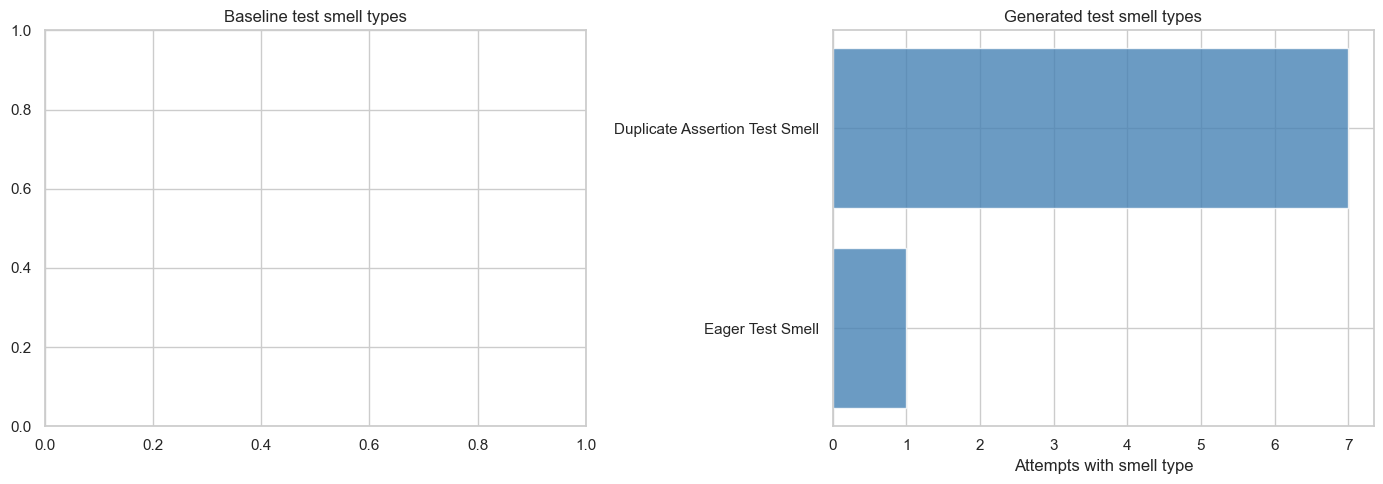

In [18]:
from analysis.plots import smell_type_breakdown

for count_col, types_col, label in [
    ('baseline_test_smell_count',  'baseline_test_smell_types',  'Baseline'),
    ('generated_test_smell_count', 'generated_test_smell_types', 'Generated'),
]:
    if count_col in repo_attempts.columns:
        total = repo_attempts[count_col].fillna(0).sum()
        with_smells = (repo_attempts[count_col].fillna(0) > 0).sum()
        print(f'{label}: total smell instances={int(total)}, attempts with smells={with_smells}/{len(repo_attempts)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smell_type_breakdown(repo_attempts, 'baseline_test_smell_types',  ax=axes[0])
axes[0].set_title('Baseline test smell types')
smell_type_breakdown(repo_attempts, 'generated_test_smell_types', ax=axes[1])
axes[1].set_title('Generated test smell types')
plt.tight_layout()
plt.show()

## 16. Timing Breakdown

Stacked bar of median generation vs validation duration per lane, and test execution time. Identifies whether the time budget is dominated by generation (model latency) or validation (build + test run).


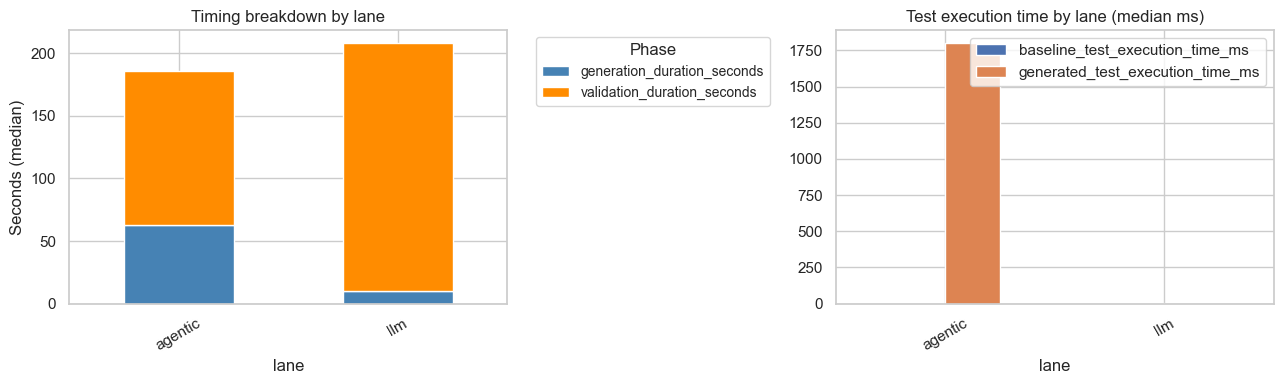


Token usage by lane:
        total_tokens           cumulative_tokens         
                 sum    median               sum   median
lane                                                     
agentic       307918  153959.0                 0      0.0
llm            43316    1782.0            199749  39731.0


In [19]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(repo_attempts, group_col='lane', ax=axes[0])

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in repo_attempts.columns]
if exec_cols:
    repo_attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time by lane (median ms)')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

token_cols = [c for c in ['total_tokens', 'cumulative_tokens'] if c in repo_attempts.columns]
if token_cols:
    print('\nToken usage by lane:')
    print(repo_attempts.groupby('lane')[token_cols].agg(['sum', 'median']))